# Sugarcane Disease Classification (PyTorch)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import os
from sklearn.metrics import classification_report, confusion_matrix

# Captum for Explainable AI
try:
    from captum.attr import IntegratedGradients
    from captum.attr import visualization as viz
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'captum'])
    from captum.attr import IntegratedGradients
    from captum.attr import visualization as viz

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


d:\ML\Sugarcane Disease\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [ ]:
# ── Hyperparameters ────────────────────────────────────────────
BATCH_SIZE = 32
IMG_SIZE_CNN  = 128   # Custom CNN
IMG_SIZE_VGG  = 224   # VGG16 requires 224×224 
DATA_DIR = 'f_data'

def make_transforms(img_size, augment=False):
    """Return a transform pipeline. Use augment=True for training."""
    ops = [transforms.Resize((img_size, img_size))]
    if augment:
        ops += [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]
    ops += [
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ]
    return transforms.Compose(ops)

def build_loaders(img_size, batch_size=BATCH_SIZE):
    # Load dataset twice: once with augmentation, once without
    full_aug    = datasets.ImageFolder(DATA_DIR, transform=make_transforms(img_size, augment=True))
    full_no_aug = datasets.ImageFolder(DATA_DIR, transform=make_transforms(img_size, augment=False))

    n = len(full_aug)
    torch.manual_seed(42)
    indices = torch.randperm(n).tolist()
    n_train = int(0.70 * n)
    n_val   = int(0.15 * n)
    # remaining goes to test

    train_idx = indices[:n_train]
    val_idx   = indices[n_train : n_train + n_val]
    test_idx  = indices[n_train + n_val:]

    train_ds = torch.utils.data.Subset(full_aug,    train_idx)   # augmented
    val_ds   = torch.utils.data.Subset(full_no_aug, val_idx)     # no augmentation
    test_ds  = torch.utils.data.Subset(full_no_aug, test_idx)    # no augmentation

    kw = dict(batch_size=batch_size, num_workers=0)
    train_loader = DataLoader(train_ds, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

    class_names = full_aug.classes
    print(f'Classes: {class_names}')
    print(f'Split sizes — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}')
    return train_loader, val_loader, test_loader, class_names

# Build separate loaders for each model (different img sizes)
train_loader_cnn, val_loader_cnn, test_loader_cnn, class_names = build_loaders(IMG_SIZE_CNN)
train_loader_vgg, val_loader_vgg, test_loader_vgg, _           = build_loaders(IMG_SIZE_VGG)


Classes: ['Healthy', 'Unhealthy']
Split sizes — train: 1680, val: 360, test: 361
Classes: ['Healthy', 'Unhealthy']
Split sizes — train: 1680, val: 360, test: 361


In [ ]:
# ── Model Definitions ──────────────────────────────────────────

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # 128×128 → 16×16 after 3 MaxPool2d
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1),   # raw logit for BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def create_vgg16_model():
    """VGG16 with frozen feature extractor; custom binary head."""
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False
    in_feats = model.classifier[0].in_features 
    model.classifier = nn.Sequential(
        nn.Linear(in_feats, 512), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(512, 1),
    )
    return model


In [ ]:
# ── Training & Evaluation Utilities ────────────────────────────

def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=20, patience=4, save_path=None):
    
    model = model.to(device)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=True
    )
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        # ── Training phase ──
        model.train()
        run_loss = correct = total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * inputs.size(0)
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.bool()).sum().item()
            total   += labels.size(0)
        train_loss = run_loss / total
        train_acc  = correct  / total

        # ── Validation phase ──
        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.float().to(device)
                outputs = model(inputs).squeeze(1)
                loss = criterion(outputs, labels)
                v_loss    += loss.item() * inputs.size(0)
                preds = torch.sigmoid(outputs) > 0.5
                v_correct += (preds == labels.bool()).sum().item()
                v_total   += labels.size(0)
        val_loss = v_loss    / v_total
        val_acc  = v_correct / v_total

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        # ── Early stopping & checkpoint ──
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  ✔ Saved best model → {save_path}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    return model, history


def evaluate_model(model, test_loader, class_names):
    """Evaluate on the held-out test set and print classification report + confusion matrix."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device)).squeeze(1)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            y_pred.extend(preds.flatten())
            y_true.extend(labels.numpy())

    print('\n--- Classification Report ---')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.title('Confusion Matrix'); plt.tight_layout(); plt.show()


def plot_history(history, title='Training History'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss')
    ax1.set_title(f'{title} — Loss'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   label='Val Acc')
    ax2.set_title(f'{title} — Accuracy'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout(); plt.show()


--- Training Custom CNN ---


d:\ML\Sugarcane Disease\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/30 | Train Loss: 1.9917  Acc: 0.6690 | Val Loss: 0.3680  Acc: 0.8694
  ✔ Saved best model → best_custom_cnn.pth
Epoch 02/30 | Train Loss: 0.4106  Acc: 0.8167 | Val Loss: 0.2395  Acc: 0.9028
  ✔ Saved best model → best_custom_cnn.pth
Epoch 03/30 | Train Loss: 0.3316  Acc: 0.8631 | Val Loss: 0.2095  Acc: 0.9250
  ✔ Saved best model → best_custom_cnn.pth
Epoch 04/30 | Train Loss: 0.2802  Acc: 0.8821 | Val Loss: 0.1709  Acc: 0.9389
  ✔ Saved best model → best_custom_cnn.pth
Epoch 05/30 | Train Loss: 0.2445  Acc: 0.9000 | Val Loss: 0.1631  Acc: 0.9278
  ✔ Saved best model → best_custom_cnn.pth
Epoch 06/30 | Train Loss: 0.2065  Acc: 0.9173 | Val Loss: 0.1539  Acc: 0.9389
  ✔ Saved best model → best_custom_cnn.pth
Epoch 07/30 | Train Loss: 0.1893  Acc: 0.9286 | Val Loss: 0.1054  Acc: 0.9528
  ✔ Saved best model → best_custom_cnn.pth
Epoch 08/30 | Train Loss: 0.1807  Acc: 0.9321 | Val Loss: 0.1125  Acc: 0.9500
Epoch 09/30 | Train Loss: 0.1655  Acc: 0.9321 | Val Loss: 0.1060  Acc: 0.95

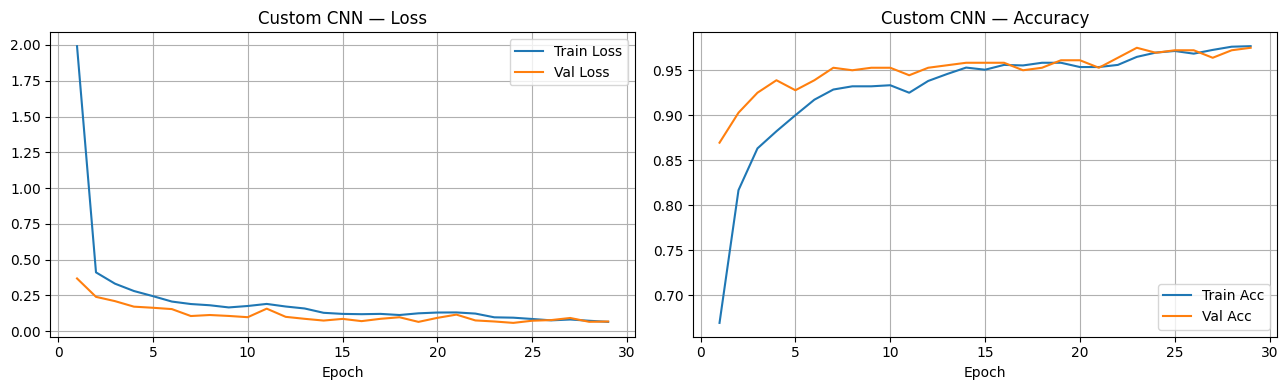

C:\Users\paulp\AppData\Local\Temp\ipykernel_5792\2904621655.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  custom_cnn_model.load_state_dict(torch.load('best_custom_cnn


--- Classification Report ---
              precision    recall  f1-score   support

     Healthy       0.95      0.96      0.96       176
   Unhealthy       0.96      0.96      0.96       185

    accuracy                           0.96       361
   macro avg       0.96      0.96      0.96       361
weighted avg       0.96      0.96      0.96       361



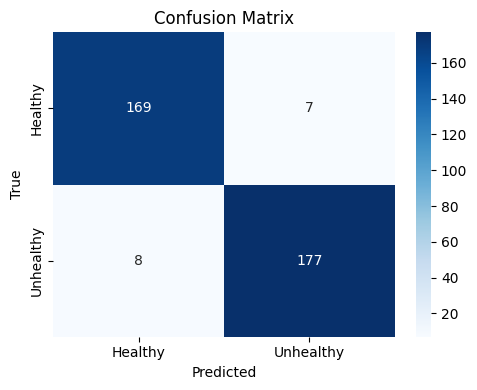

In [5]:
# ── Train Custom CNN ───────────────────────────────────────────
custom_cnn_model = CustomCNN()
criterion   = nn.BCEWithLogitsLoss()
optimizer   = optim.Adam(custom_cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

print('--- Training Custom CNN ---')
custom_cnn_model, history_cnn = train_model(
    custom_cnn_model, train_loader_cnn, val_loader_cnn,
    criterion, optimizer,
    num_epochs=30, patience=5,
    save_path='best_custom_cnn.pth'
)

plot_history(history_cnn, title='Custom CNN')

# Load best checkpoint before evaluating
custom_cnn_model.load_state_dict(torch.load('best_custom_cnn.pth', map_location=device))
evaluate_model(custom_cnn_model, test_loader_cnn, class_names)


In [ ]:
# ── Train VGG16 Transfer Learning ──────────────────────────────
vgg16_model = create_vgg16_model()
criterion   = nn.BCEWithLogitsLoss()
# Only optimise the unfrozen classifier head
optimizer   = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16_model.parameters()),
    lr=1e-4, weight_decay=1e-4
)

print('--- Training VGG16 Transfer Learning Model ---')
vgg16_model, history_vgg = train_model(
    vgg16_model, train_loader_vgg, val_loader_vgg,
    criterion, optimizer,
    num_epochs=20, patience=4,
    save_path='best_vgg16.pth'
)

plot_history(history_vgg, title='VGG16 Transfer Learning')

# Load best checkpoint before evaluating
vgg16_model.load_state_dict(torch.load('best_vgg16.pth', map_location=device))
evaluate_model(vgg16_model, test_loader_vgg, class_names)


--- Training VGG16 Transfer Learning Model ---


d:\ML\Sugarcane Disease\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/20 | Train Loss: 0.4021  Acc: 0.8095 | Val Loss: 0.2087  Acc: 0.9222
  ✔ Saved best model → best_vgg16.pth
Epoch 02/20 | Train Loss: 0.2005  Acc: 0.9280 | Val Loss: 0.1442  Acc: 0.9528
  ✔ Saved best model → best_vgg16.pth
Epoch 03/20 | Train Loss: 0.1698  Acc: 0.9393 | Val Loss: 0.1117  Acc: 0.9583
  ✔ Saved best model → best_vgg16.pth
Epoch 04/20 | Train Loss: 0.1236  Acc: 0.9589 | Val Loss: 0.1117  Acc: 0.9611
  ✔ Saved best model → best_vgg16.pth
Epoch 05/20 | Train Loss: 0.1088  Acc: 0.9625 | Val Loss: 0.0856  Acc: 0.9639
  ✔ Saved best model → best_vgg16.pth
Epoch 06/20 | Train Loss: 0.0940  Acc: 0.9661 | Val Loss: 0.0835  Acc: 0.9722
  ✔ Saved best model → best_vgg16.pth
Epoch 07/20 | Train Loss: 0.0861  Acc: 0.9714 | Val Loss: 0.0817  Acc: 0.9694
  ✔ Saved best model → best_vgg16.pth
Epoch 08/20 | Train Loss: 0.0733  Acc: 0.9732 | Val Loss: 0.0835  Acc: 0.9694
Epoch 09/20 | Train Loss: 0.0829  Acc: 0.9702 | Val Loss: 0.0915  Acc: 0.9750
Epoch 10/20 | Train Loss: 0.0758